In [43]:
import sympy as sp
from sympy import *
from IPython.display import display, Math

init_printing()


### Maple worksheet

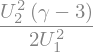

In [44]:
# Symbols
gamma = sp.symbols('gamma')

U1, U2, U3 = sp.symbols('U1 U2 U3')
U = sp.Matrix([U1, U2, U3])
# Pressure
p = (gamma - 1) * (U3 - sp.Rational(1,2) * U2**2 / U1)
# Flux components
F1 = U2
F2 = U1 * (U2/U1)**2 + p
F3 = (U2/U1) * (U3 + p)

# Flux vector
F = sp.Matrix([F1, F2, F3])

# Derivative
dF2_dU1 = sp.simplify(sp.diff(F2, U1))
dF2_dU1

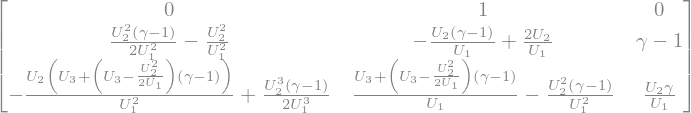

In [45]:
A = F.jacobian(U)
A

### mine

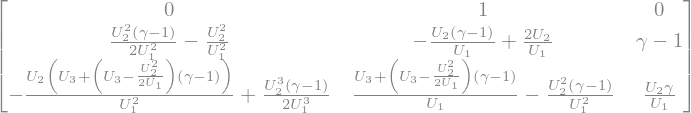

In [46]:
import sympy as sp

rho, u, E = sp.symbols('rho u E')
gamma = sp.symbols('gamma')

p = (gamma - 1) * (U3 - sp.Rational(1,2) * U2**2 / U1)
# Flux components
F1 = U2
F2 = U1 * (U2/U1)**2 + p
F3 = (U2/U1) * (U3 + p)

U1, U2, U3 = sp.symbols('U1 U2 U3')
F = sp.Matrix([F1, F2, F3])
U = sp.Matrix([U1, U2, U3])

# Jacobian dF_i / dU_j
A = F.jacobian(U)
A


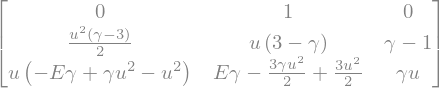

In [47]:

subs_dict = {
    U1: rho,
    U2: rho*u,
    U3: rho*E
}

A = sp.simplify(A.subs(subs_dict))
A


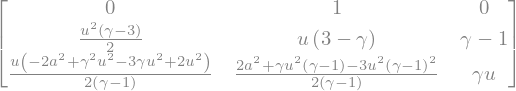

In [48]:
cv, T, a, R = sp.symbols('cv T a R')
thermo_subs = {
    E:cv*T + u**2/2,
    cv:R/(gamma - 1),
    T: a**2 / (gamma * R)
}
A= A.subs(thermo_subs)
# A.eigenvals()
A.simplify()


In [49]:
Maple_A31 = -gamma*u*(sp.Rational(1,2)*u**2 + a**2/((gamma-1)*gamma)) + (gamma-1)*u**3
Maple_A32 = gamma*(sp.Rational(1,2)*u**2 + a**2/((gamma-1)*gamma)) - sp.Rational(3,2)*(gamma-1)*u**2
A31 = sp.simplify(A[2,0])
A32 = sp.simplify(A[2,1])
print("Check A31:", sp.simplify(A31 - Maple_A31))
print("Check A32:", sp.simplify(A32 - Maple_A32))

Check A31: 0
Check A32: 0


In [100]:
list(A.eigenvals().keys())

In [142]:
eigenvalues[0]

Qa =


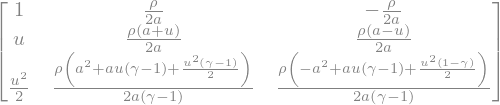

In [222]:
# Example
Aeigenvects = A.eigenvects()

# Extract only eigenvectors (as a list of lists of vectors)
eigenvectors = [v for _, _, vects in Aeigenvects for v in vects]
eigenvalues = [v for v, _, _ in Aeigenvects ]
r1= eigenvectors[0]*(1/eigenvectors[0][0])
r3= -eigenvectors[1]*(1/eigenvectors[1][0])
r2= eigenvectors[2]*(1/eigenvectors[2][0])
lambda1 = eigenvalues[0]
lambda3 = eigenvalues[1] 
lambda2 = eigenvalues[2]
Qa = Matrix.hstack(r1, r2, r3)

# Optional: display
print("Qa =")
def clean_vector(v):
    return Matrix([collect((simplify(entry)), [u**2/2,  a**2,u*a]) for entry in v])

r1_clean = clean_vector(r1)
r2_clean = clean_vector(r2)*rho/2/a
r3_clean = clean_vector(r3)*(rho/2/a)
Qa = Matrix.hstack(r1_clean, r2_clean, r3_clean)
Qa

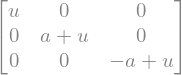

In [224]:
Lambda = diag(lambda1, lambda2, lambda3)
Lambda

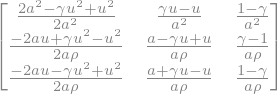

In [ ]:
Qa.inv()

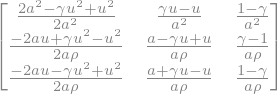

In [279]:
Qa_inv = Qa.inv()
Qa_inv

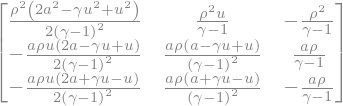

In [ ]:
simplify(Qa_inv/((gamma-1)/(rho*a)))


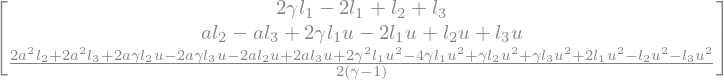

In [ ]:
l1,l2,l3=sp.symbols('l1 l2 l3')
subs_dict = {
    U1: rho,
    U2: rho*u,
    U3: rho*E
}
U=U.subs(subs_dict).subs(thermo_subs)
Lambda_sym = diag(l1, l2, l3)
F =Qa*Lambda_sym*Qa_inv*U
factor(simplify(F)/(rho/(2*gamma)))
